# Notebook 4 — Autoencoder: diagnostica (anomaly detection)

**Ruolo nel progetto:** terzo pilastro — **diagnostica** (manutenzione predittiva), accanto a
consumo/eco-driving (NB2) e contesto+stili di guida (NB3).

**Obiettivo.** Individuare in modo *non supervisionato* punti di telemetria **anomali** —
combinazioni di sensori insolite, potenziali derive/guasti — con un **autoencoder**: una rete che
impara a ricostruire i dati "normali"; cio' che ricostruisce male (errore alto) e' candidato anomalia.

**Perche' nel progetto.** Un veicolo connesso non serve solo a stimare consumi (NB2) o riconoscere
strada/stile (NB3): puo' fare **diagnostica**. I `Fuel_Trim` (correzioni della centralina alla
miscela) sono l'indicatore classico: valori grandi/persistenti segnalano problemi.

**Perche' un autoencoder e non una soglia.** Una soglia coglie solo anomalie *univariate*. L'AE
impara la **struttura congiunta** dei segnali: segnala un punto anche quando ogni singolo valore e'
"nella norma" ma la **combinazione** e' implausibile.

**Powertrain incluso come feature.** Includiamo `EngineType` (one-hot): per HEV/PHEV il motore
spento in marcia (MAF=0) e' **normale**, non un guasto. Dando il tipo motore alla rete, l'AE impara
il "normale" *per powertrain* e non scambia la trazione elettrica per anomalia.

**Tecniche del corso:** autoencoder (Keras 3 / backend PyTorch), StandardScaler, train/val split,
errore di ricostruzione come anomaly score; confronto con **Isolation Forest**; PCA.

**Onesta' metodologica.** Niente etichette di guasto -> validazione **qualitativa** (distribuzione
errore, ispezione casi, accordo con un secondo metodo). La soglia (top 1%) e' una scelta. Nel NB1 i
fuori-scala grossolani erano gia' stati rimossi: qui si cercano anomalie piu' sottili.

**Input:** `outputs/ved_enriched.parquet`.

## 1. Setup

> Keras 3 e' multi-backend: impostiamo **PyTorch** prima di importare keras.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import keras
from keras import layers

keras.utils.set_random_seed(42)
sns.set_style('whitegrid')
RANDOM_STATE = 42
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.14.1 | backend: torch


## 2. Dati e feature

Segnali fisici/di sensore per la diagnostica: cuore i **fuel trim**, piu' stato operativo (velocita',
accel, RPM, carico, MAF) e contesto (OAT, slope). Aggiungiamo `EngineType` (one-hot) per modellare il
normale per powertrain. Qui RPM/Load sono leciti: stiamo *descrivendo* lo stato, non predicendo in
anticipo.

In [3]:
DATA = Path("./outputs/ved_enriched.parquet")
AE_NUM = [
    'Vehicle_Speed_km_per_h', 'accel_kmh_s', 'Engine_RPM_RPM', 'Absolute_Load_pct',
    'MAF_g_per_sec', 'OAT_DegC', 'slope',
    'Short_Term_Fuel_Trim_Bank_1_pct', 'Long_Term_Fuel_Trim_Bank_1_pct',
]
SAMPLE_N = 200_000

df = pd.read_parquet(DATA, columns=AE_NUM + ['EngineType'])
df = df.dropna(subset=AE_NUM).sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Righe: {len(df):,} | feature numeriche: {len(AE_NUM)} | + EngineType one-hot")
print(df['EngineType'].value_counts().to_string())

Righe: 200,000 | feature numeriche: 9 | + EngineType one-hot
EngineType
ICE     116110
HEV      59918
PHEV     23972


## 3. Standardizzazione (numeriche) + one-hot (EngineType) e split

StandardScaler sulle numeriche (l'AE minimizza l'MSE: senza scaling le feature a range ampio
dominerebbero). `EngineType` -> one-hot, concatenato alle numeriche scalate.

In [4]:
scaler = StandardScaler()
X_num = scaler.fit_transform(df[AE_NUM].values)
dummies = pd.get_dummies(df['EngineType'], prefix='eng')
FEAT_NAMES = AE_NUM + list(dummies.columns)
X = np.hstack([X_num, dummies.values]).astype('float32')

X_train, X_val = train_test_split(X, test_size=0.2, random_state=RANDOM_STATE)
print("X:", X.shape, "| feature totali:", len(FEAT_NAMES), "->", FEAT_NAMES)

X: (200000, 12) | feature totali: 12 -> ['Vehicle_Speed_km_per_h', 'accel_kmh_s', 'Engine_RPM_RPM', 'Absolute_Load_pct', 'MAF_g_per_sec', 'OAT_DegC', 'slope', 'Short_Term_Fuel_Trim_Bank_1_pct', 'Long_Term_Fuel_Trim_Bank_1_pct', 'eng_HEV', 'eng_ICE', 'eng_PHEV']


## 4. Architettura dell'autoencoder

Autoencoder denso a clessidra con **bottleneck = 3** (forza la compressione: la rete deve tenere solo
la struttura essenziale). Uscita lineare (ricostruiamo valori reali), loss **MSE**.

In [5]:
n_features = X.shape[1]
inp = keras.Input(shape=(n_features,))
e = layers.Dense(16, activation='relu')(inp)
e = layers.Dense(8, activation='relu')(e)
z = layers.Dense(3, activation='relu', name='bottleneck')(e)
d = layers.Dense(8, activation='relu')(z)
d = layers.Dense(16, activation='relu')(d)
out = layers.Dense(n_features, activation='linear')(d)
autoencoder = keras.Model(inp, out, name='telemetry_autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
autoencoder.summary()

Model: "telemetry_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751 (2.93 KB)

 Trainable params: 751 (2.93 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

Epoch 1/50
313/313 - 3s - 11ms/step - loss: 0.6119 - val_loss: 0.4511
Epoch 2/50
313/313 - 3s - 9ms/step - loss: 0.4174 - val_loss: 0.3945
Epoch 3/50
313/313 - 3s - 9ms/step - loss: 0.3764 - val_loss: 0.3516
Epoch 4/50
313/313 - 3s - 9ms/step - loss: 0.3385 - val_loss: 0.3295
Epoch 5/50
313/313 - 3s - 9ms/step - loss: 0.3218 - val_loss: 0.3160
Epoch 6/50
313/313 - 3s - 8ms/step - loss: 0.3114 - val_loss: 0.3077
Epoch 7/50
313/313 - 3s - 9ms/step - loss: 0.3044 - val_loss: 0.3019
Epoch 8/50
313/313 - 3s - 9ms/step - loss: 0.2995 - val_loss: 0.2980
Epoch 9/50
313/313 - 3s - 9ms/step - loss: 0.2956 - val_loss: 0.2953
Epoch 10/50
313/313 - 3s - 9ms/step - loss: 0.2927 - val_loss: 0.2919
Epoch 11/50
313/313 - 3s - 9ms/step - loss: 0.2906 - val_loss: 0.2901
Epoch 12/50
313/313 - 3s - 8ms/step - loss: 0.2890 - val_loss: 0.2888
Epoch 13/50
313/313 - 3s - 9ms/step - loss: 0.2877 - val_loss: 0.2878
Epoch 14/50
313/313 - 3s - 9ms/step - loss: 0.2865 - val_loss: 0.2864
Epoch 15/50
313/313 - 3s - 9

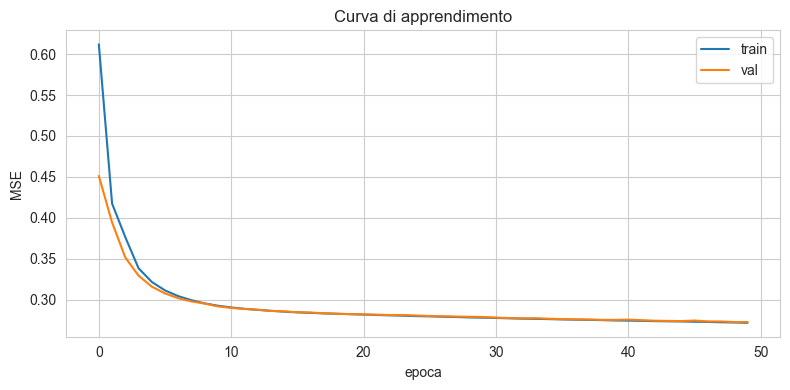

In [6]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = autoencoder.fit(X_train, X_train, validation_data=(X_val, X_val),
                          epochs=50, batch_size=512, callbacks=[es], verbose=2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'], label='train'); ax.plot(history.history['val_loss'], label='val')
ax.set_xlabel('epoca'); ax.set_ylabel('MSE'); ax.set_title('Curva di apprendimento'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Errore di ricostruzione = anomaly score

MSE per riga = anomaly score. Soglia al **99° percentile** (top 1%). E' una scelta operativa.

Soglia (99o pct): 2.411 | anomalie AE: 2,000 (1.00%)


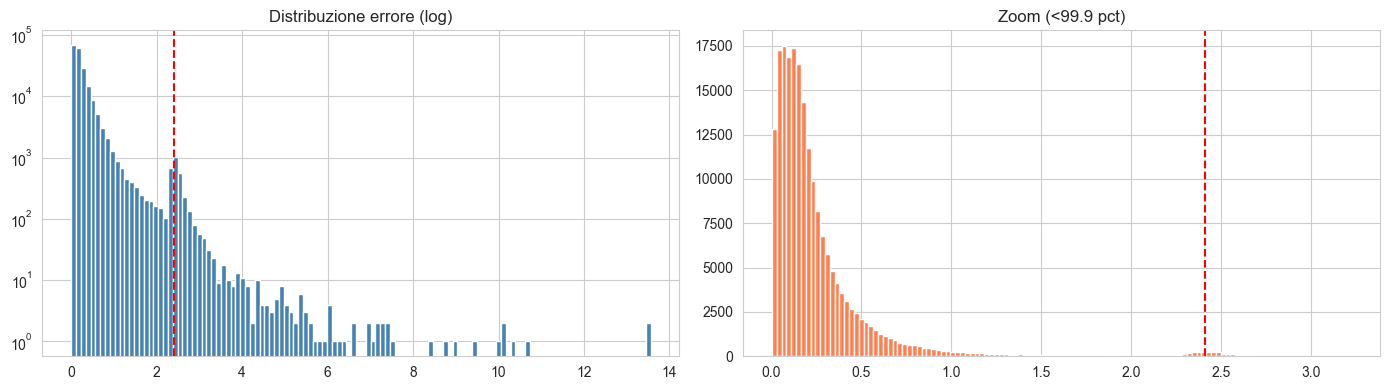

In [7]:
X_pred = autoencoder.predict(X, batch_size=2048, verbose=0)
recon_err = np.mean((X - X_pred) ** 2, axis=1)
THRESH_PCT = 99
thr = np.percentile(recon_err, THRESH_PCT)
is_anom_ae = recon_err > thr
print(f"Soglia ({THRESH_PCT}o pct): {thr:.3f} | anomalie AE: {is_anom_ae.sum():,} ({is_anom_ae.mean()*100:.2f}%)")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(recon_err, bins=120, color='steelblue'); axes[0].axvline(thr, color='red', ls='--')
axes[0].set_yscale('log'); axes[0].set_title('Distribuzione errore (log)')
axes[1].hist(recon_err[recon_err < np.percentile(recon_err, 99.9)], bins=120, color='coral')
axes[1].axvline(thr, color='red', ls='--'); axes[1].set_title('Zoom (<99.9 pct)')
plt.tight_layout(); plt.show()

## 7. Quali sensori "spiegano" le anomalie?

Errore di ricostruzione per singola feature: media sui punti anomali vs normali.

                        feature  err_anomalie  err_normali  rapporto
                          slope     23.200001         0.28 84.010002
Short_Term_Fuel_Trim_Bank_1_pct      3.650000         0.43  8.400000
 Long_Term_Fuel_Trim_Bank_1_pct      3.710000         0.55  6.780000
                       OAT_DegC      0.220000         0.04  4.860000
                  MAF_g_per_sec      0.380000         0.13  2.890000
              Absolute_Load_pct      0.900000         0.39  2.300000
                 Engine_RPM_RPM      0.230000         0.13  1.740000
         Vehicle_Speed_km_per_h      0.480000         0.32  1.510000
                        eng_HEV      0.210000         0.16  1.270000
                        eng_ICE      0.190000         0.16  1.240000
                       eng_PHEV      0.060000         0.05  1.090000
                    accel_kmh_s      0.310000         0.31  0.980000


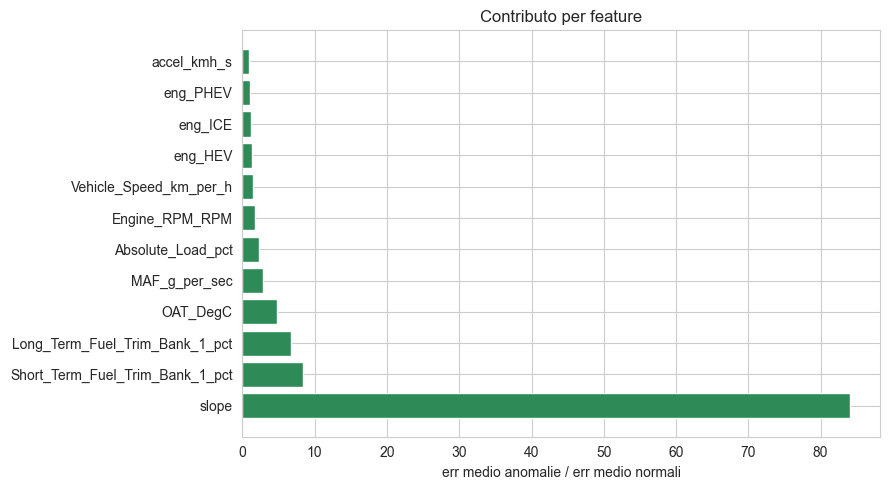

In [8]:
err_per_feat = (X - X_pred) ** 2
norm_mask = ~is_anom_ae
contrib = pd.DataFrame({
    'feature': FEAT_NAMES,
    'err_anomalie': err_per_feat[is_anom_ae].mean(axis=0),
    'err_normali':  err_per_feat[norm_mask].mean(axis=0),
})
contrib['rapporto'] = contrib['err_anomalie'] / contrib['err_normali'].replace(0, np.nan)
contrib = contrib.sort_values('rapporto', ascending=False)
print(contrib.round(2).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(contrib['feature'], contrib['rapporto'].fillna(0), color='seagreen')
ax.set_xlabel('err medio anomalie / err medio normali'); ax.set_title('Contributo per feature')
plt.tight_layout(); plt.show()

## 8. Confronto con Isolation Forest

Metodo unsupervised indipendente (isola i punti con partizioni casuali). Se concorda con l'AE sui
casi estremi, la fiducia aumenta. `contamination=0.01` per confrontarlo con la soglia all'1%.

In [9]:
iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
is_anom_iso = iso.fit_predict(X) == -1
print(f"Anomalie IsolationForest: {is_anom_iso.sum():,} ({is_anom_iso.mean()*100:.2f}%)")
both = (is_anom_ae & is_anom_iso).sum(); union = (is_anom_ae | is_anom_iso).sum()
print(f"Concordi: {both:,} | Jaccard: {both/union:.3f}")
print(f"Solo AE: {(is_anom_ae & ~is_anom_iso).sum():,} | Solo IsoForest: {(~is_anom_ae & is_anom_iso).sum():,}")

Anomalie IsolationForest: 2,000 (1.00%)
Concordi: 262 | Jaccard: 0.070
Solo AE: 1,738 | Solo IsoForest: 1,738


## 9. Ispezione dei casi piu' anomali

In [10]:
top_idx = np.argsort(recon_err)[-10:][::-1]
cols_show = AE_NUM + ['EngineType']
median_normal = df.loc[norm_mask, AE_NUM].median()
view = df.iloc[top_idx][cols_show].copy()
view.insert(0, 'recon_err', recon_err[top_idx].round(2))
print("MEDIANA punti normali:"); print(median_normal.round(2).to_string())
print("\nTOP 10 anomalie:"); print(view.round(2).to_string(index=False))

MEDIANA punti normali:
Vehicle_Speed_km_per_h               44.00
accel_kmh_s                           0.00
Engine_RPM_RPM                     1253.00
Absolute_Load_pct                    26.45
MAF_g_per_sec                         5.54
OAT_DegC                              9.00
slope                                 0.00
Short_Term_Fuel_Trim_Bank_1_pct       0.00
Long_Term_Fuel_Trim_Bank_1_pct        0.78

TOP 10 anomalie:
 recon_err  Vehicle_Speed_km_per_h  accel_kmh_s  Engine_RPM_RPM  Absolute_Load_pct  MAF_g_per_sec  OAT_DegC  slope  Short_Term_Fuel_Trim_Bank_1_pct  Long_Term_Fuel_Trim_Bank_1_pct EngineType
     13.56                    49.0          2.5           974.0          14.900000       2.520000     28.00    0.0                        85.940002                        0.140000        ICE
     13.51                    18.0        -15.0           879.0          14.900000       2.700000     42.00    0.0                        89.839996                        5.470000        ICE

## 10. Visualizzazione PCA

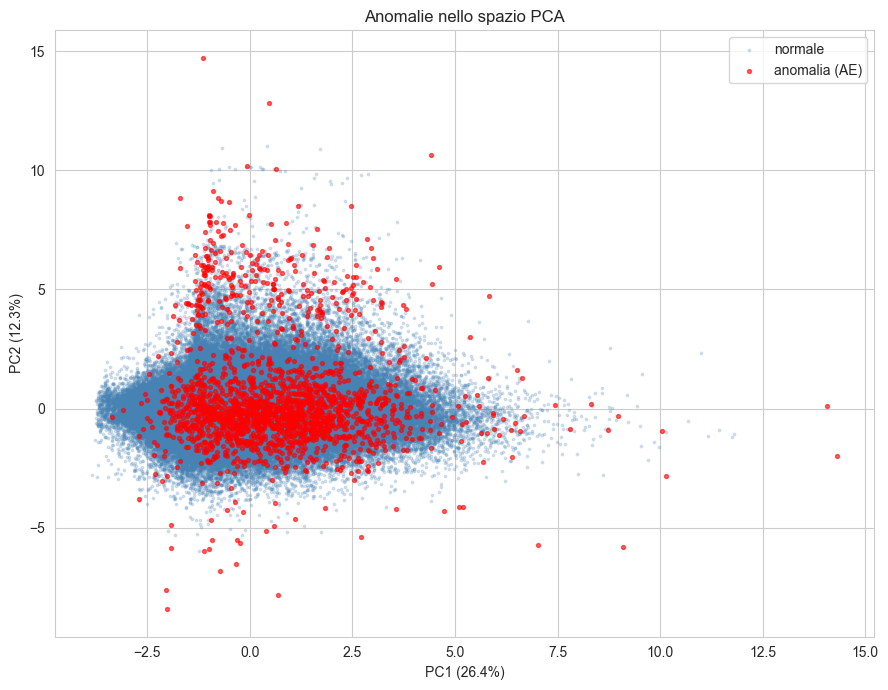

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Z[norm_mask, 0], Z[norm_mask, 1], s=3, alpha=0.2, color='steelblue', label='normale')
ax.scatter(Z[is_anom_ae, 0], Z[is_anom_ae, 1], s=8, alpha=0.6, color='red', label='anomalia (AE)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Anomalie nello spazio PCA'); ax.legend(); plt.tight_layout(); plt.show()

## 11. Salvataggio

In [12]:
Path('./outputs').mkdir(exist_ok=True)
autoencoder.save('./outputs/telemetry_autoencoder.keras')
out = df.copy(); out['recon_err'] = recon_err; out['anomaly_ae'] = is_anom_ae; out['anomaly_iso'] = is_anom_iso
out.to_parquet('./outputs/anomaly_scores.parquet', index=False)
print("Salvati: telemetry_autoencoder.keras, anomaly_scores.parquet")

Salvati: telemetry_autoencoder.keras, anomaly_scores.parquet


---
## Riepilogo

- **Autoencoder** denso (bottleneck 3) che impara la telemetria normale; errore di ricostruzione =
  anomaly score (soglia 99° pct).
- **EngineType incluso**: il "motore spento in marcia" degli ibridi e' trattato come normale, non
  come anomalia.
- Contributo per-feature, confronto con **Isolation Forest** (Jaccard), ispezione casi, PCA.
- **Limiti:** niente etichette -> validazione qualitativa; soglia = scelta; l'AE modella la massa
  dei dati.
- Copre l'argomento **autoencoder** ed e' il pilastro diagnostica del progetto.